Data Preparation

In [5]:

#Loading and cleaning of data

import pandas as pd
import numpy as np

# Load dataset
url = "https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv"
df = pd.read_csv(url)
print(df.head())

# Filling missing values
df = df.fillna(0)

# Encoding categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])


   id         hotel  is_canceled  lead_time  arrival_date_year  \
0   1  Resort Hotel          0.0      342.0               2015   
1   2  Resort Hotel          0.0      737.0               2015   
2   3  Resort Hotel          0.0        7.0               2015   
3   4  Resort Hotel          0.0       13.0               2015   
4   5  Resort Hotel          0.0       14.0               2015   

  arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
0               July                      27.0                        1.0   
1               July                      27.0                        1.0   
2               July                      27.0                        1.0   
3               July                      27.0                        1.0   
4               July                      27.0                        1.0   

   stays_in_weekend_nights  stays_in_week_nights  ...  deposit_type  agent  \
0                      0.0                   0.0  ...    No De

Task 1: Baseline Model


In [ ]:
# Spliting of data
from sklearn.model_selection import train_test_split

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
ROC-AUC: 1.0
Confusion Matrix:
 [[15000     0]
 [    0  8878]]


Task 2: Curse of Dimensionality

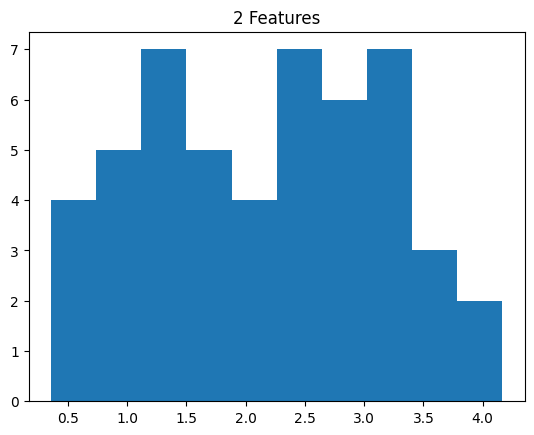

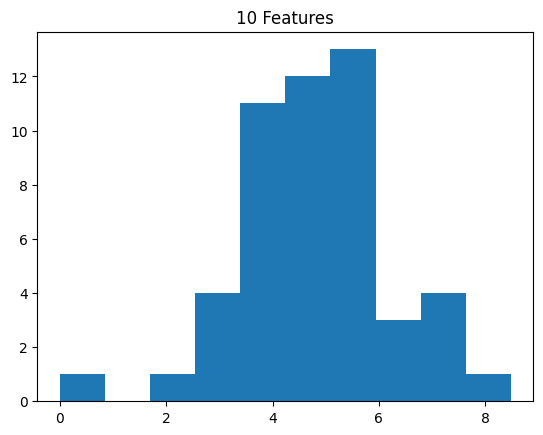

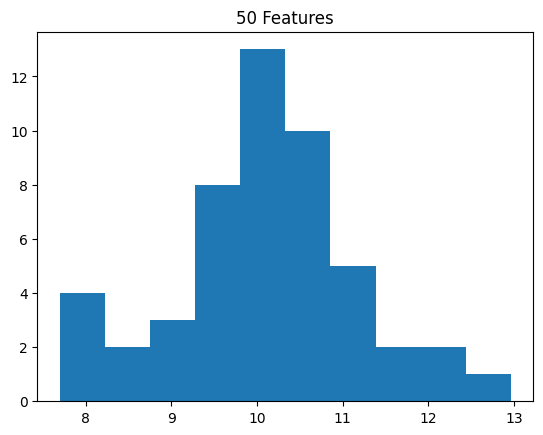

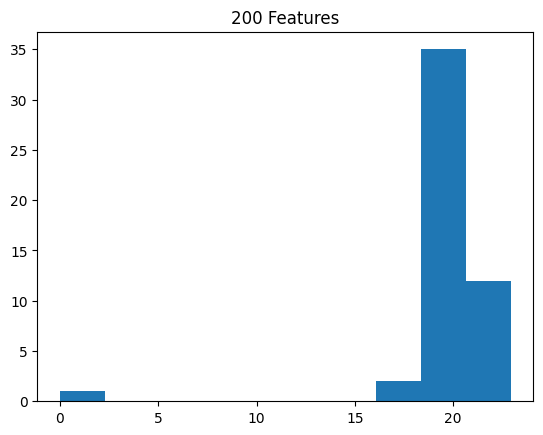

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

def plot_distance(n):
    # Adjust n_informative to be less than n_features when n is small
    n_informative = max(1, min(n - 1, 2))

    # Adjust n_clusters_per_class to be less than or equal to n_informative,
    # specifically when n_informative is 1 (which happens when n=2).
    n_clusters = 1 if n_informative == 1 else 2

    X_temp, _ = make_classification(
        n_samples=200,
        n_features=n,
        n_informative=n_informative,
        n_redundant=0,
        n_repeated=0,
        n_clusters_per_class=n_clusters
    )

    distances = []
    for i in range(50):
        a, b = np.random.randint(0, 200, 2)
        d = np.linalg.norm(X_temp[a] - X_temp[b])
        distances.append(d)

    plt.hist(distances)
    plt.title(f"{n} Features")
    plt.show()

plot_distance(2)
plot_distance(10)
plot_distance(50)
plot_distance(200)

Task 3: Numeric Preprocessing

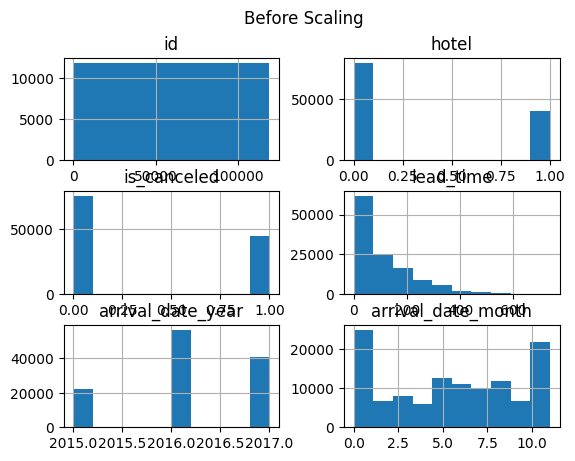

Before Scaling:
                   id          hotel    is_canceled      lead_time  \
count  119390.000000  119390.000000  119390.000000  119390.000000   
mean    59695.500000       0.335539       0.370416     104.005553   
std     34465.068657       0.472181       0.482918     106.866236   
min         1.000000       0.000000       0.000000       0.000000   
25%     29848.250000       0.000000       0.000000      18.000000   
50%     59695.500000       0.000000       0.000000      69.000000   
75%     89542.750000       1.000000       1.000000     160.000000   
max    119390.000000       1.000000       1.000000     737.000000   

       arrival_date_year  arrival_date_month  
count      119390.000000       119390.000000  
mean         2016.156554            5.490544  
std             0.707476            3.535075  
min          2015.000000            0.000000  
25%          2016.000000            2.000000  
50%          2016.000000            6.000000  
75%          2017.000000        

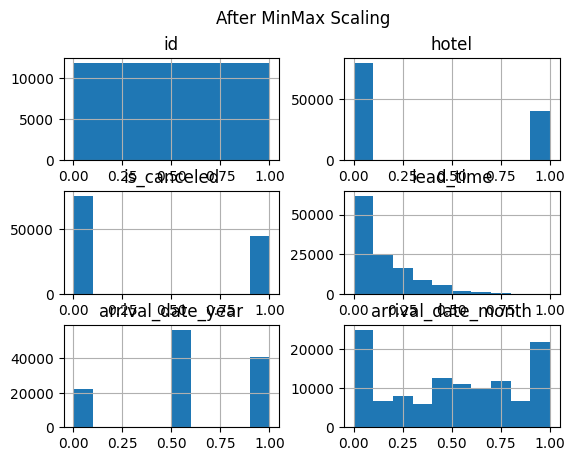

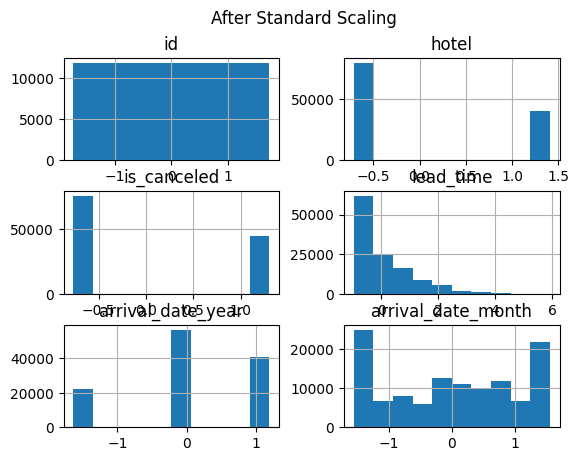

After Standard Scaling:
                  id         hotel   is_canceled     lead_time  \
count  1.193900e+05  1.193900e+05  1.193900e+05  1.193900e+05   
mean   1.523569e-17 -7.998739e-17 -5.713385e-17  3.047139e-17   
std    1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00   
min   -1.732036e+00 -7.106189e-01 -7.670405e-01 -9.732353e-01   
25%   -8.660182e-01 -7.106189e-01 -7.670405e-01 -8.047997e-01   
50%    0.000000e+00 -7.106189e-01 -7.670405e-01 -3.275656e-01   
75%    8.660182e-01  1.407224e+00  1.303712e+00  5.239698e-01   
max    1.732036e+00  1.407224e+00  1.303712e+00  5.923266e+00   

       arrival_date_year  arrival_date_month  
count       1.193900e+05        1.193900e+05  
mean       -8.406294e-14       -6.856062e-17  
std         1.000004e+00        1.000004e+00  
min        -1.634768e+00       -1.553168e+00  
25%        -2.212864e-01       -9.874072e-01  
50%        -2.212864e-01        1.441154e-01  
75%         1.192195e+00        7.098766e-01  
max         1

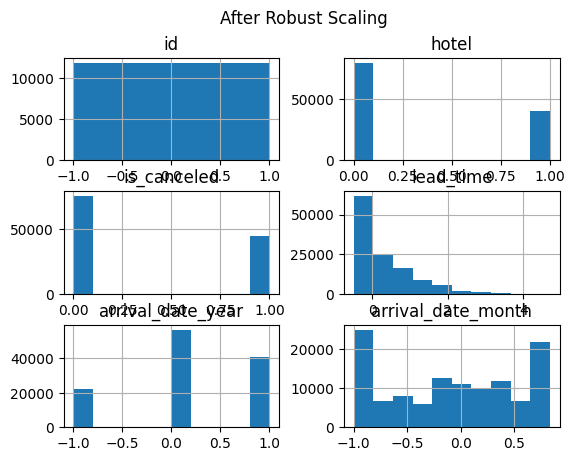

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt

# Use 6 numeric columns
num_cols = df.select_dtypes(include=np.number).columns[:6]

# Before scaling
df[num_cols].hist()
plt.suptitle("Before Scaling")
plt.show()

print("Before Scaling:\n", df[num_cols].describe())

# MinMaxScaler
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df[num_cols]), columns=num_cols)

df_minmax.hist()
plt.suptitle("After MinMax Scaling")
plt.show()

# StandardScaler
standard = StandardScaler()
df_standard = pd.DataFrame(standard.fit_transform(df[num_cols]), columns=num_cols)

df_standard.hist()
plt.suptitle("After Standard Scaling")
plt.show()

print("After Standard Scaling:\n", df_standard.describe())

# RobustScaler
robust = RobustScaler()
df_robust = pd.DataFrame(robust.fit_transform(df[num_cols]), columns=num_cols)

df_robust.hist()
plt.suptitle("After Robust Scaling")
plt.show()

# Binning
df["lead_time_bin"] = pd.cut(df["lead_time"], bins=5)

# Binarization
df["high_adr"] = (df["adr"] > 100).astype(int)

Task 4: KNN Distance Impact

In [9]:
from sklearn.neighbors import KNeighborsClassifier

X_small = df[["lead_time", "adr"]]
y_small = df["is_canceled"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_small)

# Euclidean
knn_euclidean = KNeighborsClassifier(metric='euclidean')
knn_euclidean.fit(X_scaled, y_small)

# Manhattan
knn_manhattan = KNeighborsClassifier(metric='manhattan')
knn_manhattan.fit(X_scaled, y_small)

print("Euclidean:", knn_euclidean.score(X_scaled, y_small))
print("Manhattan:", knn_manhattan.score(X_scaled, y_small))

Euclidean: 0.8075634475249184
Manhattan: 0.8078984839601306


Task 5: Pipeline

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np # Import numpy for np.log1p

# Modify log_transform to handle potential negative values by capping them at 0
log_transform = FunctionTransformer(lambda x: np.log1p(np.maximum(0, x)))

X = df.drop(columns=["is_canceled", "lead_time_bin"], errors='ignore')
y = df["is_canceled"]

# Identify numeric columns from X for the 'num' preprocessor
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("log", log_transform),
        ("scale", StandardScaler())
    ]), numeric_features)
], remainder='passthrough') # Pass th

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

scores = cross_val_score(pipeline, X, y, cv=5)

print("Pipeline Score:", scores.mean())

Pipeline Score: 0.9351453220537733


Task 6: Feature Extraction



In [14]:
df["total_people"] = df["adults"] + df["children"]
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

df["arrival_day"] = df["arrival_date_day_of_month"]
df["is_weekend"] = (df["arrival_day"] > 5).astype(int)

df["booking_changes_flag"] = (df["booking_changes"] > 0).astype(int)
df["arrival_month"] = df["arrival_date_month"]

Task 7: Feature Construction

In [15]:
# Ratio Features
df["price_per_person"] = df["adr"] / (df["adults"] + 1)
df["requests_per_night"] = df["total_of_special_requests"] / (df["total_nights"] + 1)

# Interaction Features
df["adr_lead"] = df["adr"] * df["lead_time"]
df["people_nights"] = df["total_people"] * df["total_nights"]

# Aggregation Features
df["avg_adr_country"] = df.groupby("country")["adr"].transform("mean")
df["avg_lead_hotel"] = df.groupby("hotel")["lead_time"].transform("mean")

# Polynomial Features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2, include_bias=False)
poly_features = poly.fit_transform(df[["adr", "lead_time"]])

Task 8: Feature Importance


In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier # Added import

model = RandomForestClassifier() # Added model instantiation
model.fit(X, y)

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(15))

mi = mutual_info_classif(X, y)

print("Top MI:", mi[:10])

# Correlation filtering
corr = df.corr(numeric_only=True)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
df = df.drop(columns=to_drop)

print("Dropped:", to_drop)

                        Feature  Importance
30           reservation_status    0.562874
0                            id    0.167323
22                 deposit_type    0.052705
13                      country    0.029037
12                         meal    0.027151
2                     lead_time    0.022358
1                         hotel    0.021478
17       previous_cancellations    0.014493
29    total_of_special_requests    0.013091
14               market_segment    0.012737
3             arrival_date_year    0.010919
23                        agent    0.010560
28  required_car_parking_spaces    0.008664
27                          adr    0.007224
20           assigned_room_type    0.006167
Top MI: [5.53421584e-01 1.31662570e-02 8.06155539e-02 6.41578701e-03
 3.93241173e-03 5.34076597e-03 2.05171665e-04 5.36329115e-03
 1.15166849e-02 9.91119725e-03]
Dropped: ['total_nights', 'arrival_day', 'arrival_month', 'price_per_person', 'requests_per_night', 'adr_lead', 'people_nights']


Model

In [21]:
# Final Model
 from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_final = df.drop(columns=["is_canceled", "lead_time_bin"], errors='ignore')
y_final = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.9998743613367954
